In [1]:
import os
import numpy as np
import pandas as pd

# Nền tảng Học máy

## Phần 1, Phần c: Bài thực hành EDA

## Giới thiệu

Chúng ta sẽ sử dụng tập dữ liệu iris cho hướng dẫn này. Đây là một tập dữ liệu nổi tiếng chứa các loài iris và các phép đo đo lường cánh và đài hoa. Dữ liệu chúng ta sẽ sử dụng nằm trong một tệp gọi là `iris_data.csv` được tìm thấy trong thư mục [data](data/).


In [2]:
filepath = "../../data/iris_data.csv"
data = pd.read_csv(filepath)
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Câu hỏi 1

Tải dữ liệu từ tệp bằng các kỹ thuật đã học hôm nay. Kiểm tra nó.

Xác định những điều sau:

* Số lượng điểm dữ liệu (hàng). (*Gợi ý:* kiểm tra thuộc tính `.shape` của dataframe.)
* Tên các cột. (*Gợi ý:* kiểm tra thuộc tính `.columns` của dataframe.)
* Các kiểu dữ liệu cho từng cột. (*Gợi ý:* kiểm tra thuộc tính `.dtypes` của dataframe.)


In [4]:
### BEGIN SOLUTION
# Print the title from metadata if available
if hasattr(data, 'attrs') and 'title' in data.attrs:
    print("Title:", data.attrs['title'])
else:
    print("Title: Iris Dataset")  # fallback if no metadata

# Print other metadata if available
print("File path:", filepath)
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])
print("Column names:", data.columns.tolist())
print("Data types:\n", data.dtypes)
print("First 5 rows:\n", data.head())
print("Missing values per column:\n", data.isnull().sum())
print("Unique values per column:")
for col in data.columns:
    print(f"  {col}: {data[col].nunique()} unique values")
### END SOLUTION

Title: Iris Dataset
File path: ../../data/iris_data.csv
Number of rows: 150
Number of columns: 5
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Data types:
 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object
First 5 rows:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Missing values per column:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Unique values per column:
  sepal_length: 35 unique values
  sepal_width: 23 unique values
  petal_length: 43 unique values
  petal_width:

## Câu hỏi 2

Kiểm tra tên các loài và lưu ý rằng chúng đều bắt đầu bằng 'Iris-'. Xóa phần này khỏi tên để tên loài ngắn hơn.

*Gợi ý:* có nhiều cách để làm điều này, nhưng bạn có thể sử dụng các phương pháp xử lý chuỗi hoặc phương pháp apply.


In [3]:
data['species'] = data.species.str.replace('Iris-', '')

# In tên các loài và số lượng mỗi loại
print("Tên các loài và số lượng:")
print(data['species'].value_counts())
print("\n")
print("Chi tiết:")
for species, count in data['species'].value_counts().items():
    print(f"  {species}: {count} mẫu")

data.head()

Tên các loài và số lượng:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Chi tiết:
  setosa: 50 mẫu
  versicolor: 50 mẫu
  virginica: 50 mẫu


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Câu hỏi 3

Xác định những điều sau:

* Số lượng mỗi loài có mặt. (*Gợi ý:* kiểm tra phương pháp `.value_counts` của series.)
* Giá trị trung bình, trung vị, phân vị và khoảng (max-min) cho mỗi phép đo đai hoa và đai ngoài.

*Gợi ý:* câu hỏi cuối cùng, phương pháp `.describe` có trung vị, nhưng nó không được gọi là trung vị. Đó là phân vị *50%*. `.describe` không có khoảng, và để có được khoảng, bạn sẽ cần tạo một mục nhập mới trong bảng `.describe`, là `max - min`.


In [5]:
# Select just the rows desired from the 'describe' method and add in the 'median'
stats_df = data.describe()
stats_df = data.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

out_fields = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range']
stats_df = stats_df.loc[out_fields]
stats_df.rename({'50%': 'median'}, inplace=True)
stats_df

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
median,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000
range,3.600000,2.400000,5.900000,2.400000


## Câu hỏi 4

Tính toán những điều sau **cho mỗi loài** trong một dataframe riêng biệt:

* Giá trị trung bình của mỗi phép đo (sepal_length, sepal_width, petal_length, petal_width).
* Trung vị của mỗi phép đo này.

*Gợi ý:* bạn có thể muốn sử dụng phương pháp `groupby` của Pandas để nhóm theo loài trước khi tính toán thống kê.

Nếu bạn hoàn thành cả hai, hãy thử tính toán cả hai thống kê (trung bình và trung vị) trong một bảng duy nhất (tức là với một lệnh groupby duy nhất).


In [8]:
### BEGIN SOLUTION
# The mean calculation
data.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [9]:
# The median calculation
data.groupby('species').median()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


In [10]:
# applying multiple functions at once - 2 methods

data.groupby('species').agg(['mean', 'median'])  # passing a list of recognized strings
data.groupby('species').agg([np.mean, np.median])  # passing a list of explicit aggregation functions

sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.418    3.4        1.464   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.244    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0

In [11]:
# If certain fields need to be aggregated differently, we can do:
from pprint import pprint

agg_dict = {field: ['mean', 'median'] for field in data.columns if field != 'species'}
agg_dict['petal_length'] = 'max'
pprint(agg_dict)
data.groupby('species').agg(agg_dict)
### END SOLUTION

{'petal_length': 'max',
 'petal_width': ['mean', 'median'],
 'sepal_length': ['mean', 'median'],
 'sepal_width': ['mean', 'median']}


sepal_length        sepal_width        petal_length petal_width  \
                   mean median        mean median          max        mean   
species                                                                      
setosa            5.006    5.0       3.418    3.4          1.9       0.244   
versicolor        5.936    5.9       2.770    2.8          5.1       1.326   
virginica         6.588    6.5       2.974    3.0          6.9       2.026   

                   
           median  
species            
setosa        0.2  
versicolor    1.3  
virginica     2.0

## Câu hỏi 5

Tạo biểu đồ phân tán `sepal_length` so với `sepal_width` bằng Matplotlib. Ghi nhãn các trục và đặt tiêu đề cho biểu đồ.


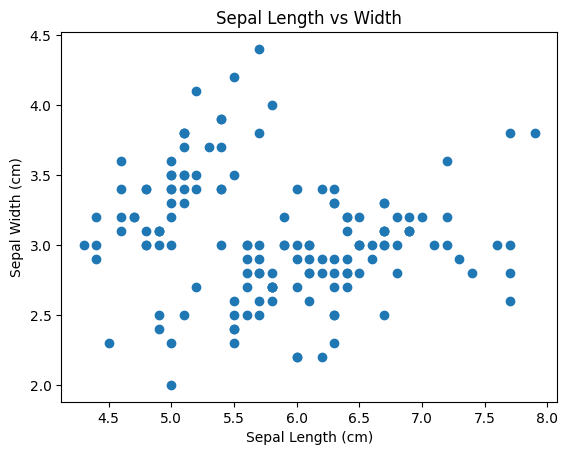

In [12]:
### BEGIN SOLUTION
import matplotlib.pyplot as plt
%matplotlib inline

# A simple scatter plot with Matplotlib
ax = plt.axes()

ax.scatter(data.sepal_length, data.sepal_width)

# Label the axes
ax.set(xlabel='Sepal Length (cm)',
       ylabel='Sepal Width (cm)',
       title='Sepal Length vs Width');
### END SOLUTION

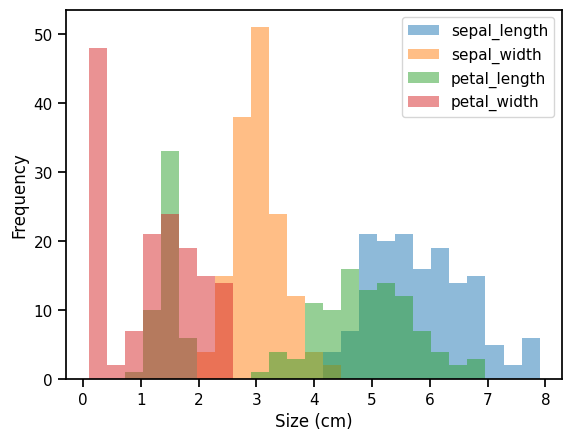

In [27]:
import seaborn as sns
sns.set_context('notebook')
### BEGIN SOLUTION
# This uses the `.plot.hist` method
ax = data.plot.hist(bins=25, alpha=0.5)
ax.set_xlabel('Size (cm)');

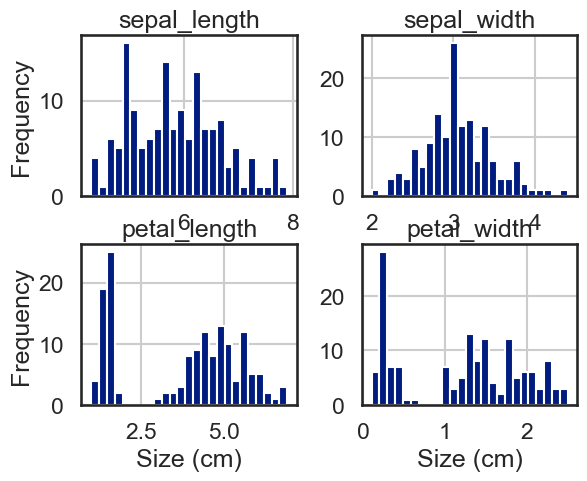

In [33]:
# To create four separate plots, use Pandas `.hist` method
axList = data.hist(bins=25)

# Add some x- and y- labels to first column and last row
for i, ax in enumerate(axList.flatten()):
    # Last row (bottom plots)
    if i >= len(axList.flatten()) - axList.shape[1]:
        ax.set_xlabel('Size (cm)')
    
    # First column (leftmost plots)    
    if i % axList.shape[1] == 0:
        ax.set_ylabel('Frequency')
### END SOLUTION

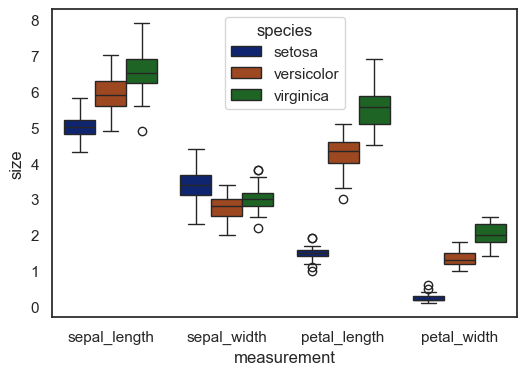

In [31]:
plot_data = (data
             .set_index('species')
             .stack()
             .to_frame()
             .reset_index()
             .rename(columns={0:'size', 'level_1':'measurement'})
            )

plot_data.head()
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
sns.boxplot(x='measurement', y='size', 
            hue='species', data=plot_data);

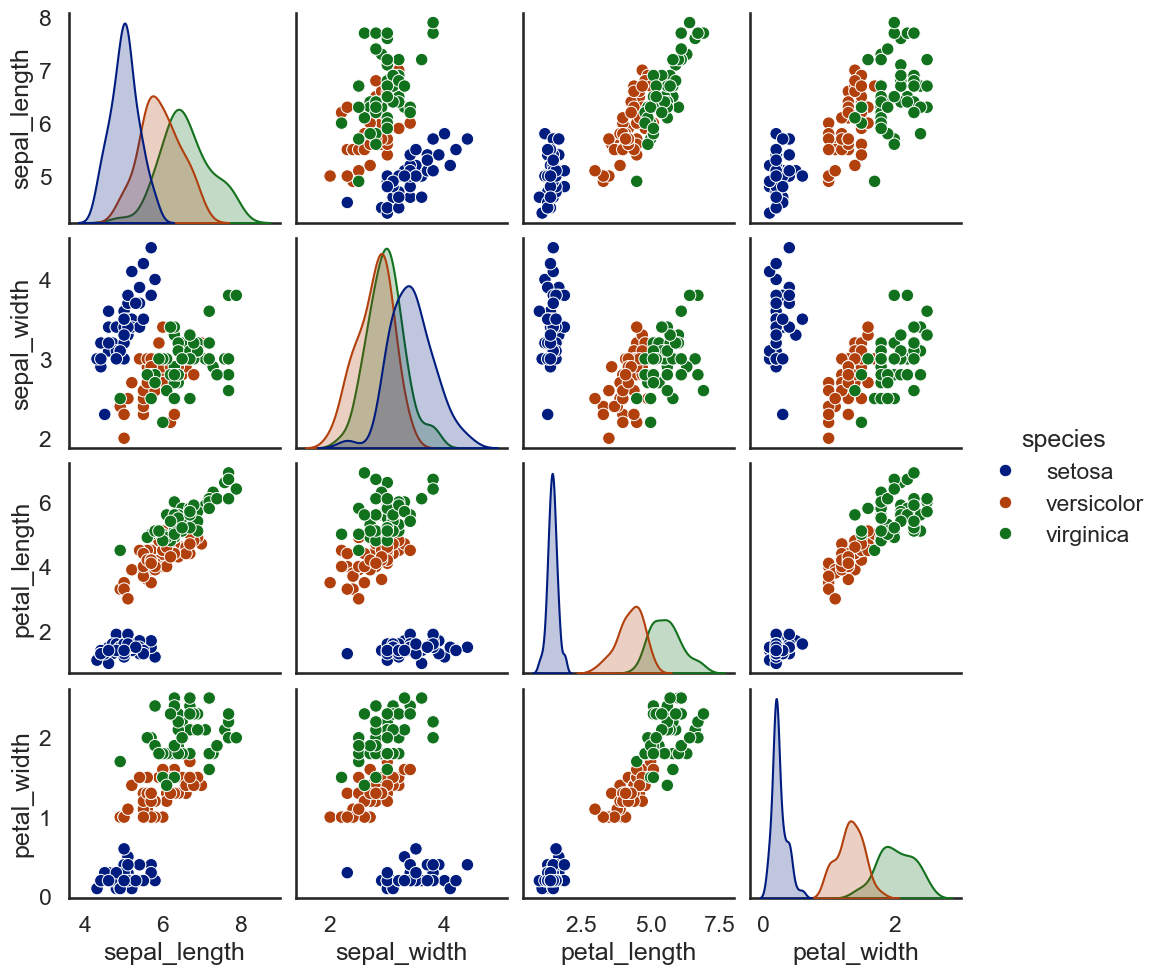

In [32]:
### BEGIN SOLUTION
sns.set_context('talk')
sns.pairplot(data, hue='species');
### END SOLUTION

## Câu hỏi 6

Sử dụng các phương pháp thống kê nâng cao để trích xuất thêm các đặc trưng từ dữ liệu. Tính toán những điều sau:

* Độ lệch chuẩn (Standard Deviation) - đo lường mức độ phân tán dữ liệu
* Phương sai (Variance) - bình phương của độ lệch chuẩn
* Hệ số biến thiên (Coefficient of Variation) - tỷ lệ giữa độ lệch chuẩn và trung bình
* Độ lệch (Skewness) - đo lường tính bất đối xứng của phân phối
* Kurtosis - đo lường độ nhọn của phân phối
* Hệ số tương quan (Correlation) - mối quan hệ giữa các biến

In [ ]:
### BEGIN SOLUTION - Phương pháp thống kê để trích xuất feature

from scipy import stats

# 1. Độ lệch chuẩn (Standard Deviation)
print("=" * 60)
print("1. ĐỘ LỆCH CHUẨN (Standard Deviation)")
print("=" * 60)
std_stats = data.groupby('species').std()
print(std_stats)
print()

# 2. Phương sai (Variance)
print("=" * 60)
print("2. PHƯƠNG SAI (Variance)")
print("=" * 60)
var_stats = data.groupby('species').var()
print(var_stats)
print()

1. ĐỘ LỆCH CHUẨN (Standard Deviation)
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.381024      0.173511     0.107210
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650

2. PHƯƠNG SAI (Variance)
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.124249     0.145180      0.030106     0.011494
versicolor      0.266433     0.098469      0.220816     0.039106
virginica       0.404343     0.104004      0.304588     0.075433



In [10]:
# 3. Hệ số biến thiên (Coefficient of Variation) = std / mean
print("=" * 60)
print("3. HỆ SỐ BIẾN THIÊN (Coefficient of Variation)")
print("=" * 60)
mean_stats = data.groupby('species').mean()
cv_stats = (std_stats / mean_stats) * 100
print("Hệ số biến thiên (%):")
print(cv_stats)
print()

# 4. Độ lệch (Skewness)
print("=" * 60)
print("4. ĐỘ LỆCH (Skewness)")
print("=" * 60)
skewness = data.groupby('species').skew()
print(skewness)
print()

# 5. Kurtosis
print("=" * 60)
print("5. KURTOSIS (độ nhọn)")
print("=" * 60)
kurt = data.groupby('species').kurt()
print(kurt)
print()
### END SOLUTION

3. HỆ SỐ BIẾN THIÊN (Coefficient of Variation)
Hệ số biến thiên (%):
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          7.041344    11.147583     11.851855    43.938321
versicolor      8.695606    11.328459     11.030774    14.913475
virginica       9.652089    10.843868      9.940466    13.556271

4. ĐỘ LỆCH (Skewness)
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.120087     0.107053      0.071846     1.197243
versicolor      0.105378    -0.362845     -0.606508    -0.031180
virginica       0.118015     0.365949      0.549445    -0.129477

5. KURTOSIS (độ nhọn)
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa         -0.252689     0.889251      1.031626     1.566442
versicolor     -0.533010    -0.366237   

## Câu hỏi 7

Tính toán ma trận tương quan (Correlation Matrix) giữa các biến số và tạo biểu đồ heatmap để trực quan hóa mối quan hệ.

6. MA TRẬN TƯƠNG QUAN (Correlation Matrix)
Hệ số tương quan Pearson:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109369      0.871754     0.817954
sepal_width      -0.109369     1.000000     -0.420516    -0.356544
petal_length      0.871754    -0.420516      1.000000     0.962757
petal_width       0.817954    -0.356544      0.962757     1.000000



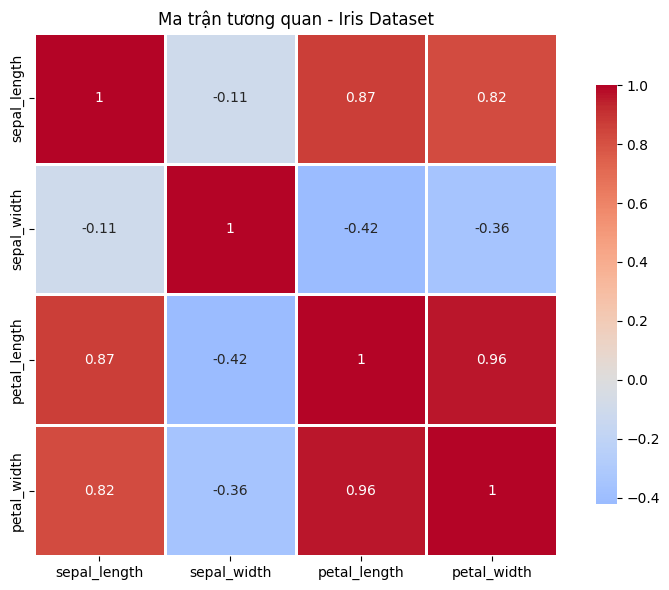

In [13]:
### BEGIN SOLUTION - Ma trận tương quan

import seaborn as sns

# 6. Ma trận tương quan (Correlation Matrix)
print("=" * 60)
print("6. MA TRẬN TƯƠNG QUAN (Correlation Matrix)")
print("=" * 60)
# Loại bỏ cột 'species' để chỉ lấy các cột số
numeric_data = data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()
print("Hệ số tương quan Pearson:")
print(corr_matrix)
print()

# Vẽ biểu đồ heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title('Ma trận tương quan - Iris Dataset')
plt.tight_layout()
plt.show()

### END SOLUTION

## Câu hỏi 8

Áp dụng các kỹ thuật trích xuất feature nâng cao: tính toán tứ phân vị, IQR (Interquartile Range), và phát hiện các giá trị ngoại lai (outliers).

In [16]:
### BEGIN SOLUTION - Phân tích tứ phân vị và phát hiện outliers

# 7. Tứ phân vị (Quartiles) và IQR
print("=" * 60)
print("7. TỨ PHÂN VỊ VÀ IQR (Interquartile Range)")
print("=" * 60)

for col in numeric_data.columns:
    Q1 = numeric_data[col].quantile(0.25)
    Q3 = numeric_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    print(f"\n{col}:")
    print(f"  Q1 (25%): {Q1:.4f} || Q3 (75%): {Q3:.4f} || IQR: {IQR:.4f}")
    
    # Phát hiện outliers bằng phương pháp IQR
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(numeric_data[col] < lower_bound) | (numeric_data[col] > upper_bound)]
    
    print(f"  Giới hạn dưới: {lower_bound:.4f}   ||   Giới hạn trên: {upper_bound:.4f}")
    print(f"  Số lượng outliers: {len(outliers)}")

### END SOLUTION

7. TỨ PHÂN VỊ VÀ IQR (Interquartile Range)

sepal_length:
  Q1 (25%): 5.1000 || Q3 (75%): 6.4000 || IQR: 1.3000
  Giới hạn dưới: 3.1500   ||   Giới hạn trên: 8.3500
  Số lượng outliers: 0

sepal_width:
  Q1 (25%): 2.8000 || Q3 (75%): 3.3000 || IQR: 0.5000
  Giới hạn dưới: 2.0500   ||   Giới hạn trên: 4.0500
  Số lượng outliers: 4

petal_length:
  Q1 (25%): 1.6000 || Q3 (75%): 5.1000 || IQR: 3.5000
  Giới hạn dưới: -3.6500   ||   Giới hạn trên: 10.3500
  Số lượng outliers: 0

petal_width:
  Q1 (25%): 0.3000 || Q3 (75%): 1.8000 || IQR: 1.5000
  Giới hạn dưới: -1.9500   ||   Giới hạn trên: 4.0500
  Số lượng outliers: 0


## Câu hỏi 9

Tạo các biểu đồ phân phối (Histogram và KDE) và biểu đồ hộp (Boxplot) để trực quan hóa các đặc trưng thống kê.

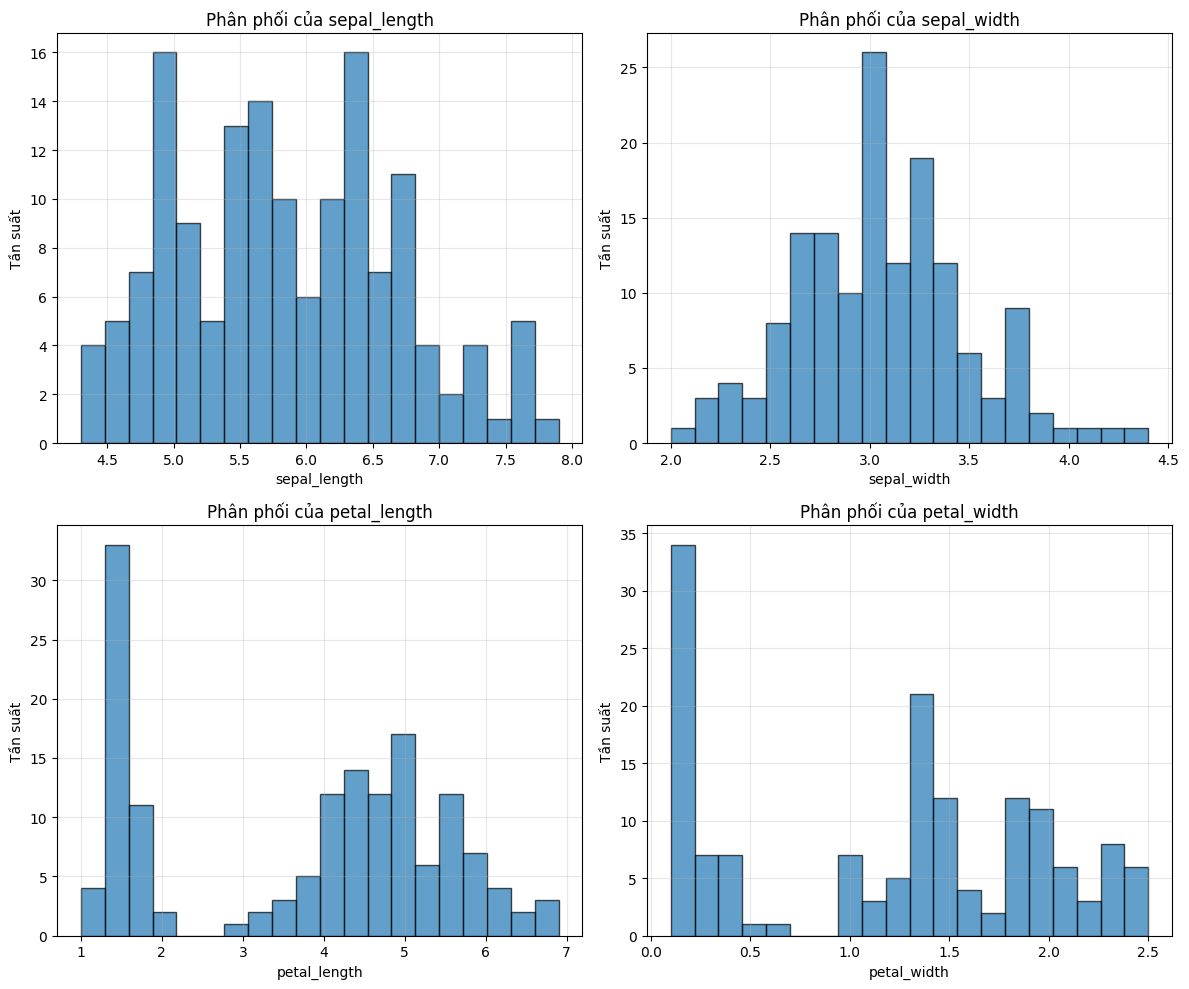

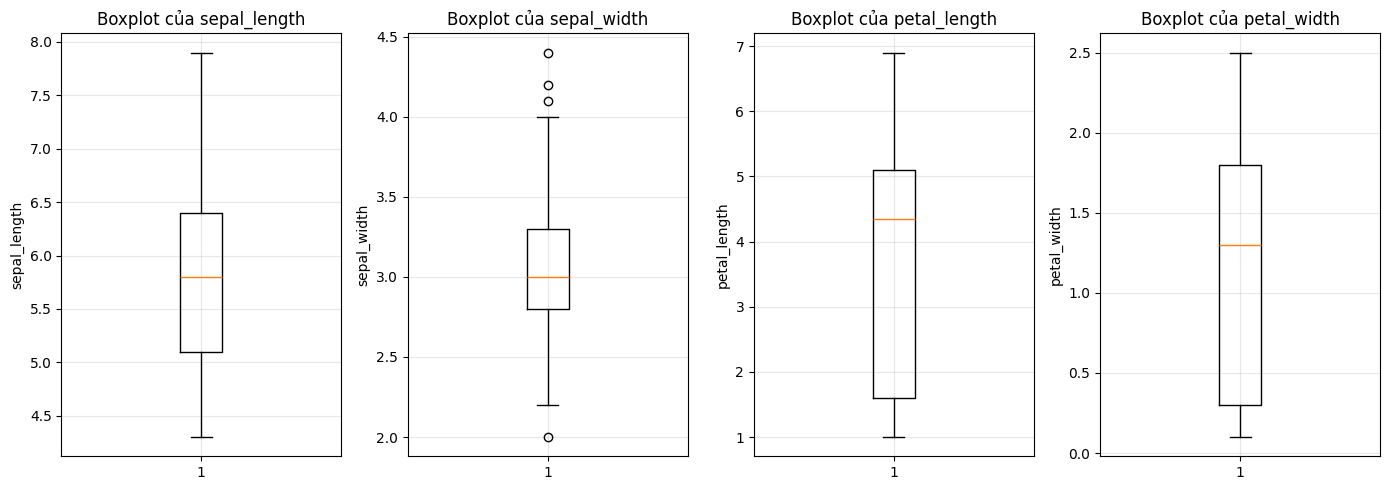

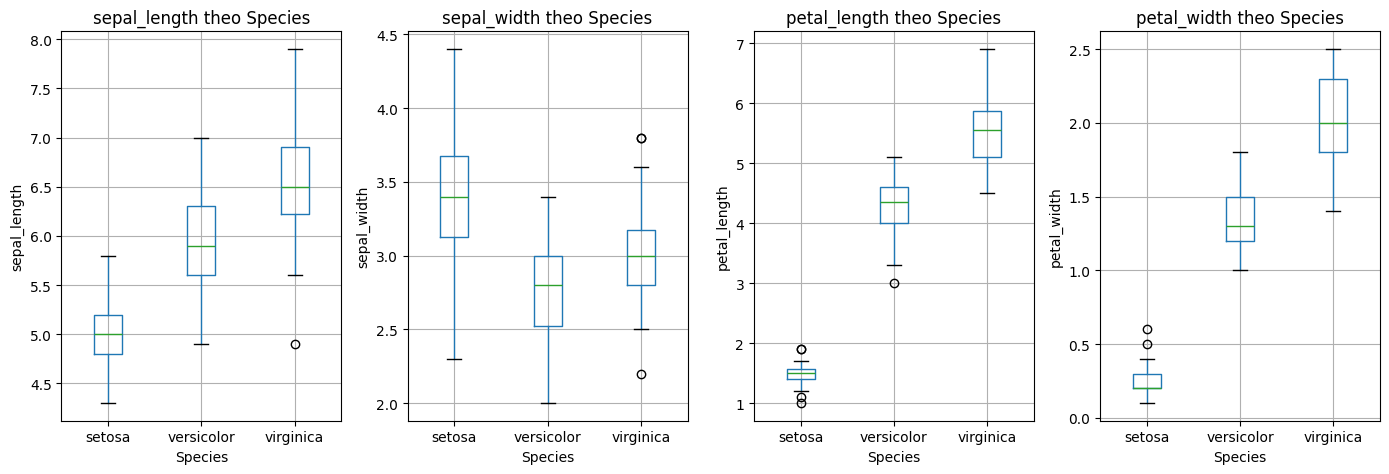

In [17]:
### BEGIN SOLUTION - Biểu đồ phân phối

# 8. Histogram và KDE plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_data.columns):
    axes[idx].hist(numeric_data[col], bins=20, alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Tần suất')
    axes[idx].set_title(f'Phân phối của {col}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Boxplot để phát hiện outliers
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for idx, col in enumerate(numeric_data.columns):
    axes[idx].boxplot(numeric_data[col])
    axes[idx].set_ylabel(col)
    axes[idx].set_title(f'Boxplot của {col}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Boxplot theo species
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for idx, col in enumerate(numeric_data.columns):
    data.boxplot(column=col, by='species', ax=axes[idx])
    axes[idx].set_title(f'{col} theo Species')
    axes[idx].set_xlabel('Species')
    axes[idx].set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

### END SOLUTION

## Câu hỏi 10

Tính toán các thống kê nâng cao khác: Entropy, Mode, và phân tích sự phân bố theo species.

In [19]:
### BEGIN SOLUTION - Phân tích nâng cao

from scipy.stats import entropy, mode

# 11. Mode (Giá trị xuất hiện nhiều nhất)
print("=" * 60)
print("11. MODE (Giá trị xuất hiện nhiều nhất)")
print("=" * 60)
for col in numeric_data.columns:
    # Rounding để tìm mode (vì dữ liệu là continuous)
    rounded = numeric_data[col].round(1)
    mode_val = rounded.mode()
    if len(mode_val) > 0:
        print(f"{col}: {mode_val[0]:.2f}")
print()

11. MODE (Giá trị xuất hiện nhiều nhất)
sepal_length: 5.00
sepal_width: 3.00
petal_length: 1.50
petal_width: 0.20



In [21]:
# 12. Entropy
print("=" * 60)
print("12. ENTROPY (Độ không chắc chắn)")
print("=" * 60)
for col in numeric_data.columns:
    # Normalize data và tính entropy
    normalized = (numeric_data[col] - numeric_data[col].min()) / (numeric_data[col].max() - numeric_data[col].min())
    # Chia thành 10 bins để tính entropy
    hist, _ = np.histogram(normalized, bins=10)
    hist = hist[hist > 0]  # Remove zeros
    entropy_val = entropy(hist / hist.sum())
    print(f"{col}: {entropy_val:.4f}")
print()

12. ENTROPY (Độ không chắc chắn)
sepal_length: 2.1618
sepal_width: 1.9636
petal_length: 1.9727
petal_width: 1.9832



In [22]:
# 13. Phân tích chi tiết theo Species
print("=" * 60)
print("13. PHÂN TÍCH CHI TIẾT THEO SPECIES")
print("=" * 60)
summary_stats = data.groupby('species')[numeric_data.columns].agg([
    'count', 'mean', 'std', 'min', 'max',
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75)),
    ('IQR', lambda x: x.quantile(0.75) - x.quantile(0.25))
])
print(summary_stats)

### END SOLUTION

13. PHÂN TÍCH CHI TIẾT THEO SPECIES
           sepal_length                                                \
                  count   mean       std  min  max     Q1   Q3    IQR   
species                                                                 
setosa               50  5.006  0.352490  4.3  5.8  4.800  5.2  0.400   
versicolor           50  5.936  0.516171  4.9  7.0  5.600  6.3  0.700   
virginica            50  6.588  0.635880  4.9  7.9  6.225  6.9  0.675   

           sepal_width         ... petal_length        petal_width         \
                 count   mean  ...           Q3    IQR       count   mean   
species                        ...                                          
setosa              50  3.418  ...        1.575  0.175          50  0.244   
versicolor          50  2.770  ...        4.600  0.600          50  1.326   
virginica           50  2.974  ...        5.875  0.775          50  2.026   

                                               
              